Лабораторная 6.

In [29]:
import random
import os, glob, json, random, shutil, cv2

import numpy as np
import torch

torch.manual_seed(52)
random.seed(52)
np.random.seed(52)

torch.backends.cudnn.benchmark = True

DEVICE = 'cuda'

In [30]:
import os
import glob

DATASET_ROOT = r'./sign_dataset'
TRAIN_DIR = os.path.join(DATASET_ROOT, 'train')
VAL_DIR = os.path.join(DATASET_ROOT, 'val')
TEST_PHOTOS_DIR = r'./test_photos'
OUTPUT_DIR = r'./yolo_dataset'
N_CLUSTERS = 8

os.makedirs(TEST_PHOTOS_DIR, exist_ok=True)


def get_image_paths(d):
    return sorted(glob.glob(os.path.join(d, '*.jpg')) + glob.glob(os.path.join(d, '*.png')))


train_images = get_image_paths(TRAIN_DIR)
val_images = get_image_paths(VAL_DIR)
print(f'Train: {len(train_images)}, Val: {len(val_images)}')

Train: 2054, Val: 127


Парсинг аннотаций via

In [31]:
def load_via_annotations(data_dir):
    via_path = os.path.join(data_dir, 'via_region_data.json')
    with open(via_path) as f:
        via = json.load(f)

    records = []
    for key, entry in via.items():
        filename = entry['filename']
        img_path = os.path.join(data_dir, filename)
        if not os.path.exists(img_path):
            continue
        regions = []
        for rid, region in entry.get('regions', {}).items():
            sa = region.get('shape_attributes', {})
            if sa.get('name') == 'polygon':
                xs = sa.get('all_points_x', [])
                ys = sa.get('all_points_y', [])
                if len(xs) >= 3 and len(ys) >= 3:
                    regions.append({'xs': xs, 'ys': ys})
        if regions:
            records.append({'img_path': img_path, 'regions': regions})
    return records


train_records = load_via_annotations(TRAIN_DIR)
val_records = load_via_annotations(VAL_DIR)

total_train_signs = sum(len(r['regions']) for r in train_records)
total_val_signs = sum(len(r['regions']) for r in val_records)
print(f'Train: {len(train_records)} изображений, {total_train_signs} знаков')
print(f'Val:   {len(val_records)} изображений, {total_val_signs} знаков')

Train: 1905 изображений, 4426 знаков
Val:   117 изображений, 312 знаков


Визуализируем несколько изображений с полигонами знаков

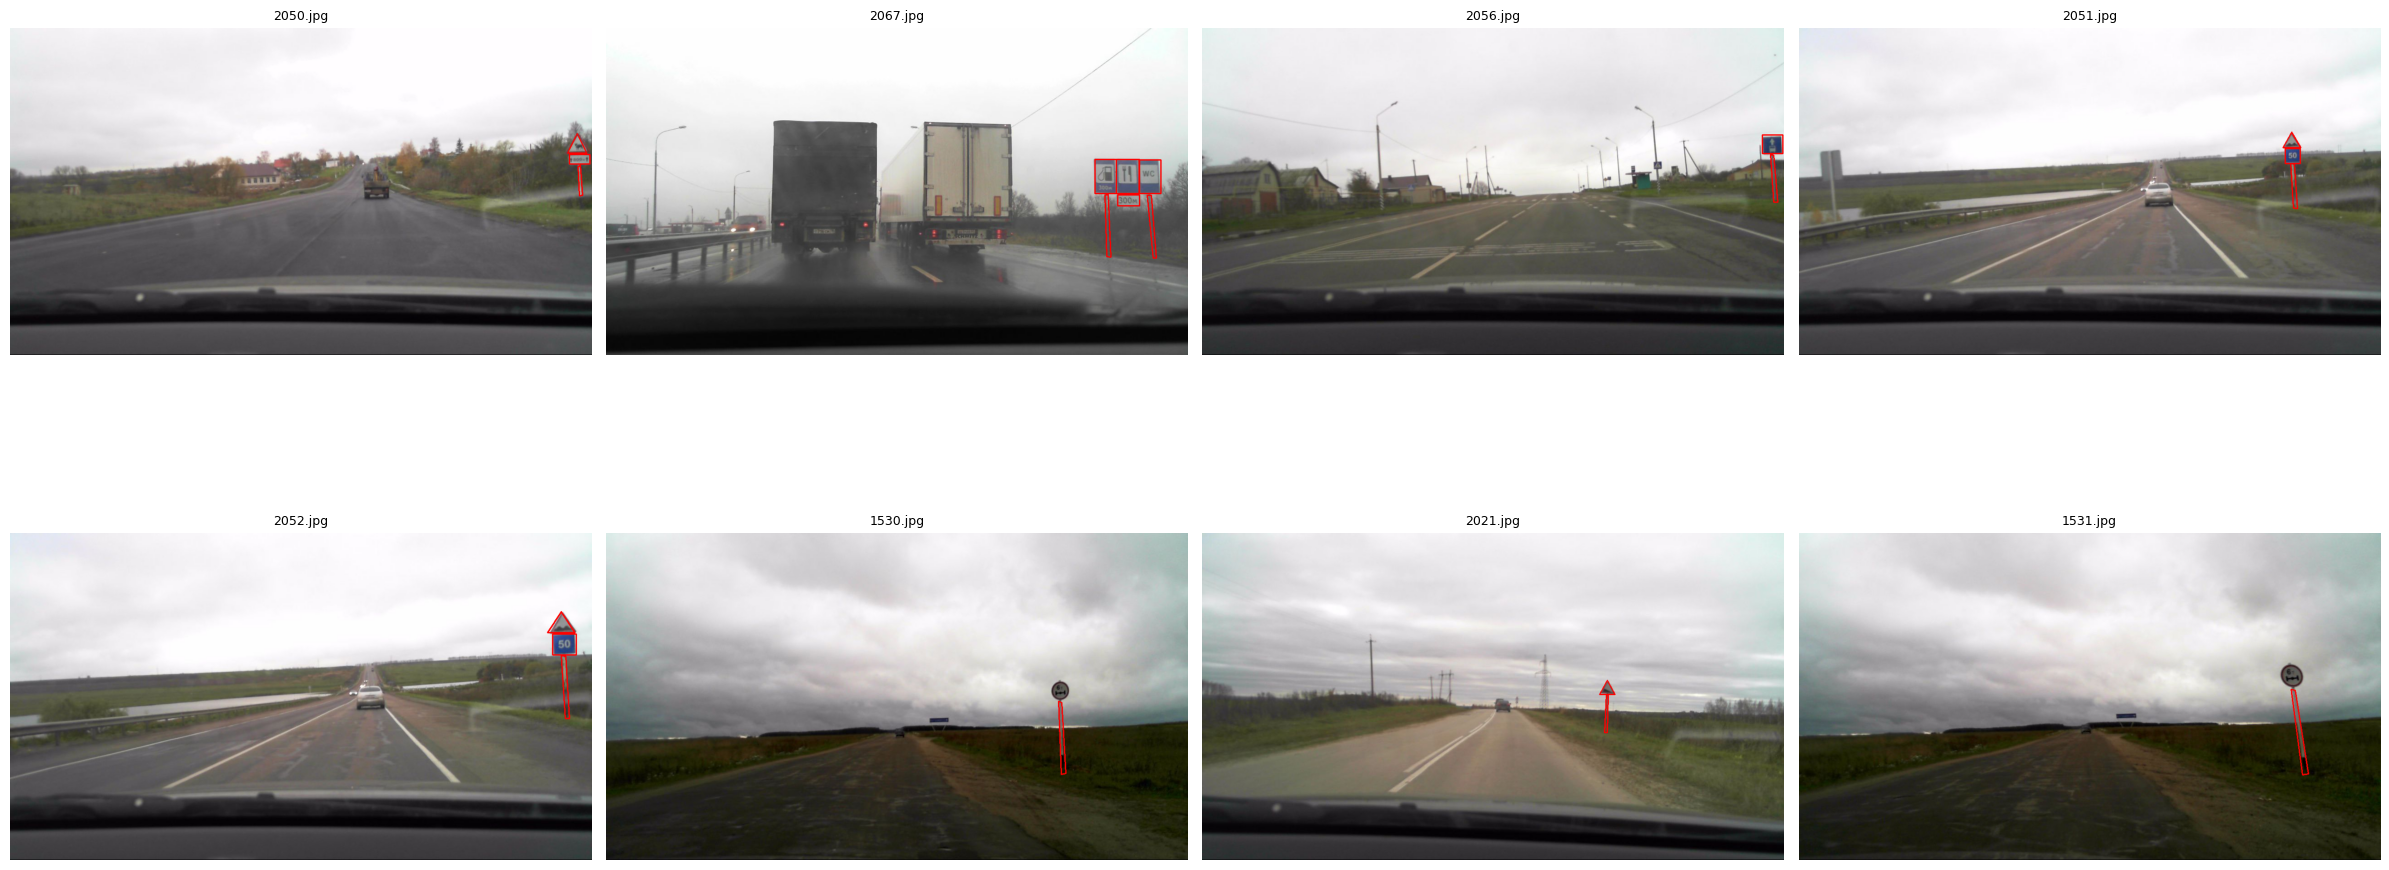

In [32]:
import cv2
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()
for i, rec in enumerate(train_records[:8]):
    img = cv2.cvtColor(cv2.imread(rec['img_path']), cv2.COLOR_BGR2RGB).copy()
    for reg in rec['regions']:
        pts = np.array(list(zip(reg['xs'], reg['ys'])), dtype=np.int32)
        cv2.polylines(img, [pts], True, (255, 0, 0), 2)
    axes[i].imshow(img)
    axes[i].set_title(Path(rec['img_path']).name, fontsize=9)
    axes[i].axis('off')
plt.tight_layout();
plt.show()

Тк знаки не разбиты на 8 классов, кластеризуем их с помощью k-means

Вырезаем кропы знаков

In [33]:
from tqdm import tqdm

CROPS_DIR = os.path.join(OUTPUT_DIR, '_crops')
os.makedirs(CROPS_DIR, exist_ok=True)

crop_info = []  # (crop_path, record_idx, region_idx)
for ri, rec in enumerate(tqdm(train_records, desc='Кропы')):
    img = cv2.imread(rec['img_path'])
    if img is None: continue
    h, w = img.shape[:2]
    for rj, reg in enumerate(rec['regions']):
        xs, ys = reg['xs'], reg['ys']
        x1, x2 = max(0, min(xs)), min(w, max(xs))
        y1, y2 = max(0, min(ys)), min(h, max(ys))
        if x2 - x1 < 5 or y2 - y1 < 5: continue
        crop = img[y1:y2, x1:x2]
        crop_path = os.path.join(CROPS_DIR, f'{ri}_{rj}.jpg')
        cv2.imwrite(crop_path, crop)
        crop_info.append((crop_path, ri, rj))

print(f'Извлечено кропов: {len(crop_info)}')

Кропы: 100%|██████████| 1905/1905 [00:09<00:00, 197.85it/s]

Извлечено кропов: 4417


Извлекаем признаки через ResNet18

In [34]:
import os, glob, json, cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
resnet.fc = nn.Identity()
resnet = resnet.to(DEVICE).eval()

tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])


class CropDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths = paths
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        return self.transform(img), idx


crop_paths = [ci[0] for ci in crop_info]
dl = DataLoader(CropDataset(crop_paths, tf), batch_size=128, shuffle=False, num_workers=0, pin_memory=True)

all_feats = []
with torch.no_grad():
    for batch, _ in tqdm(dl, desc='ResNet18'):
        all_feats.append(resnet(batch.to(DEVICE, non_blocking=True)).cpu().numpy())
features = np.concatenate(all_feats)
print(f'Фичи: {features.shape}')

ResNet18: 100%|██████████| 35/35 [00:06<00:00,  5.76it/s]

Фичи: (4417, 512)


Кластеризуем по фичам

In [35]:
from sklearn.cluster import MiniBatchKMeans

# KMeans
kmeans = MiniBatchKMeans(n_clusters=N_CLUSTERS, random_state=42, batch_size=1024)
cluster_labels = kmeans.fit_predict(features)

for u, c in zip(*np.unique(cluster_labels, return_counts=True)):
    print(f'  Кластер {u}: {c}')

  Кластер 0: 526
  Кластер 1: 187
  Кластер 2: 850
  Кластер 3: 592
  Кластер 4: 531
  Кластер 5: 523
  Кластер 6: 238
  Кластер 7: 970


Визуализируем кластера

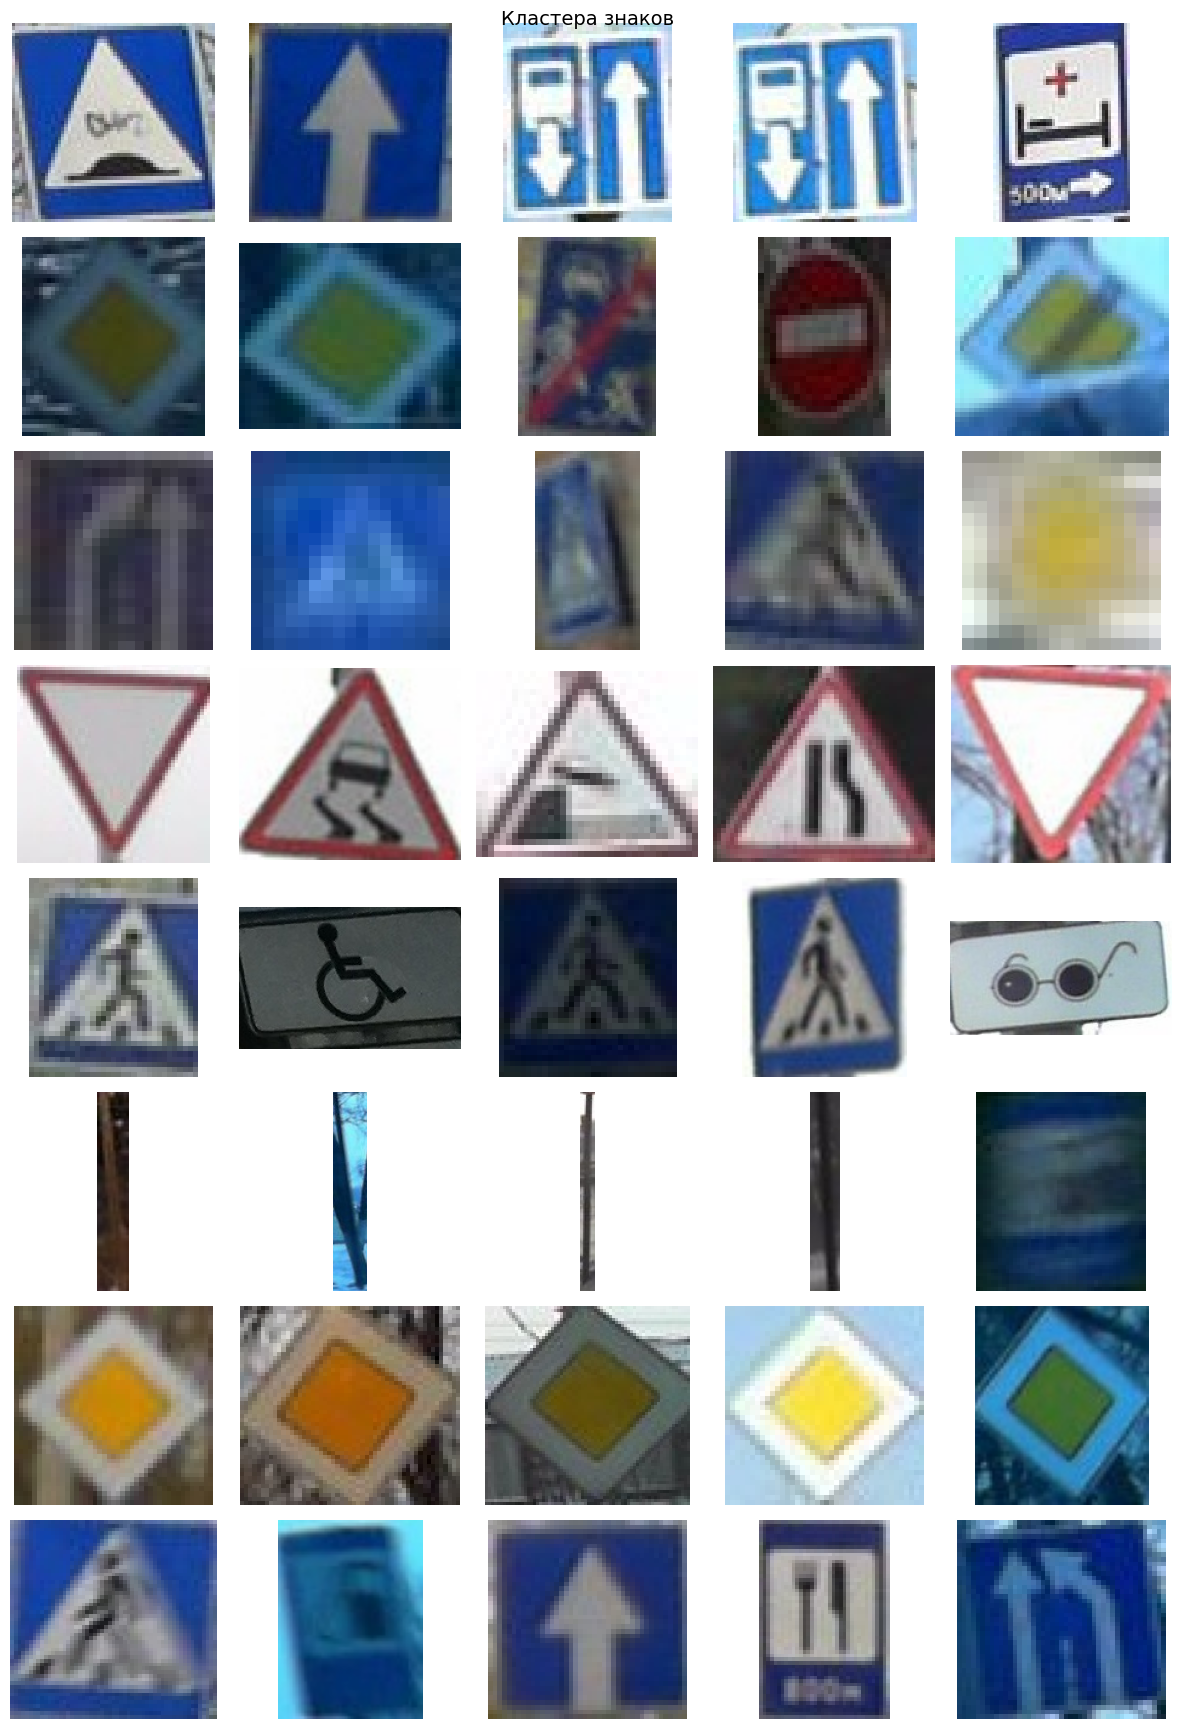

In [36]:
fig, axes = plt.subplots(N_CLUSTERS, 5, figsize=(12, N_CLUSTERS * 2.2))
for cl in range(N_CLUSTERS):
    idxs = np.where(cluster_labels == cl)[0]
    for j, idx in enumerate(np.random.choice(idxs, min(5, len(idxs)), replace=False)):
        img = cv2.cvtColor(cv2.imread(crop_paths[idx]), cv2.COLOR_BGR2RGB)
        axes[cl, j].imshow(img)
        axes[cl, j].axis('off')
    axes[cl, 0].set_ylabel(f'Тип {cl}', fontsize=10, rotation=0, labelpad=40)
plt.suptitle('Кластера знаков', fontsize=14)
plt.tight_layout();
plt.savefig('clusters_preview.png', dpi=100);
plt.show()

Конвертация в YOLO формат

In [37]:
import shutil

cluster_map = {}
for ci_idx, (_, ri, rj) in enumerate(crop_info):
    cluster_map[(ri, rj)] = int(cluster_labels[ci_idx])


def predict_cluster_for_crop(img_crop_bgr):
    crop_pil = Image.fromarray(cv2.cvtColor(img_crop_bgr, cv2.COLOR_BGR2RGB))
    t = tf(crop_pil).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        feat = resnet(t).cpu().numpy()
    return int(kmeans.predict(feat)[0])


def convert_records_to_yolo(records, split_name, is_train=True):
    img_dir = os.path.join(OUTPUT_DIR, split_name, 'images')
    lbl_dir = os.path.join(OUTPUT_DIR, split_name, 'labels')
    os.makedirs(img_dir, exist_ok=True)
    os.makedirs(lbl_dir, exist_ok=True)

    total = 0
    for ri, rec in enumerate(tqdm(records, desc=split_name)):
        img = cv2.imread(rec['img_path'])
        if img is None: continue
        h, w = img.shape[:2]

        lines = []
        for rj, reg in enumerate(rec['regions']):
            xs, ys = reg['xs'], reg['ys']

            if is_train and (ri, rj) in cluster_map:
                cls_id = cluster_map[(ri, rj)]
            else:
                x1, x2 = max(0, min(xs)), min(w, max(xs))
                y1, y2 = max(0, min(ys)), min(h, max(ys))
                if x2 - x1 < 5 or y2 - y1 < 5: continue
                crop = img[y1:y2, x1:x2]
                cls_id = predict_cluster_for_crop(crop)

            coords = ' '.join(f'{x / w:.4f} {y / h:.4f}' for x, y in zip(xs, ys))
            lines.append(f'{cls_id} {coords}')
            total += 1

        if lines:
            fname = Path(rec['img_path']).name
            shutil.copy2(rec['img_path'], os.path.join(img_dir, fname))
            with open(os.path.join(lbl_dir, Path(fname).stem + '.txt'), 'w') as f:
                f.write('\n'.join(lines) + '\n')

    print(f'{split_name}: {total} знаков')


convert_records_to_yolo(train_records, 'train', is_train=True)
convert_records_to_yolo(val_records, 'val', is_train=False)

train: 100%|██████████| 1905/1905 [00:09<00:00, 191.51it/s]


train: 4417 знаков


val: 100%|██████████| 117/117 [00:02<00:00, 48.22it/s]

val: 312 знаков


Создаём конфиг для YOLO dataset.yaml

In [38]:
yaml_lines = [
    f'path: {os.path.abspath(OUTPUT_DIR)}',
    'train: train/images',
    'val: val/images',
    '',
    'names:',
]
for i in range(N_CLUSTERS):
    yaml_lines.append(f'  {i}: sign_type_{i}')

yaml_content = '\n'.join(yaml_lines) + '\n'
yaml_path = os.path.join(OUTPUT_DIR, 'dataset.yaml')
with open(yaml_path, 'w') as f:
    f.write(yaml_content)
print(yaml_content)

path: C:\Users\mrsiz\PycharmProjects\ml-26-labs\yolo_dataset
train: train/images
val: val/images

names:
  0: sign_type_0
  1: sign_type_1
  2: sign_type_2
  3: sign_type_3
  4: sign_type_4
  5: sign_type_5
  6: sign_type_6
  7: sign_type_7



Обучение YOLOv8-seg, используем самую легкую модель YOLOv8n-seg

In [39]:
from ultralytics import YOLO

model = YOLO('yolov8n-seg.pt')

results = model.train(
    data=yaml_path, epochs=30, imgsz=640, batch=64,
    device=DEVICE, workers=0, amp=True, patience=10,
    save=True, project='runs/segment', name='road_signs',
    exist_ok=True, seed=42, lr0=0.01, optimizer='SGD',
    close_mosaic=5, plots=True,
)

New https://pypi.org/project/ultralytics/8.4.37 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.36  Python-3.11.9 torch-2.12.0.dev20260403+cu128 CUDA:0 (NVIDIA GeForce RTX 5060 Ti, 16311MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=5, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./yolo_dataset\dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale

Загружаем лучшую модель

In [40]:
model = YOLO('runs/segment/runs/segment/road_signs/weights/best.pt')

 Метрики: IoU, Precision, Recall, L2

In [41]:
def compute_metrics(pred_mask, gt_mask):
    p = (pred_mask > 0.5).astype(np.uint8)
    g = (gt_mask > 0.5).astype(np.uint8)
    inter = np.logical_and(p, g).sum()
    union = np.logical_or(p, g).sum()
    return {
        'iou': inter / union if union else 0.,
        'precision': inter / p.sum() if p.sum() else 0.,
        'recall': inter / g.sum() if g.sum() else 0.,
        'l2': np.sqrt(np.mean((p.astype(float) - g.astype(float)) ** 2))
    }


def gt_mask_from_via(rec, h, w):
    """GT маска из VIA полигонов."""
    out = np.zeros((h, w), np.uint8)
    for reg in rec['regions']:
        pts = np.array(list(zip(reg['xs'], reg['ys'])), dtype=np.int32)
        cv2.fillPoly(out, [pts], 1)
    return out


def pred_combined_mask(result, h, w):
    out = np.zeros((h, w), np.uint8)
    if result.masks is not None:
        for m in result.masks.data:
            m2 = cv2.resize(m.cpu().numpy(), (w, h))
            out = np.maximum(out, (m2 > 0.5).astype(np.uint8))
    return out


# Оценка на val
eval_records = val_records if val_records else train_records[:100]
all_metrics = []
for rec in tqdm(eval_records, desc='Eval'):
    img = cv2.imread(rec['img_path'])
    if img is None: continue
    h, w = img.shape[:2]
    gt = gt_mask_from_via(rec, h, w)
    res = model.predict(img, verbose=False, device=DEVICE, imgsz=640)
    pred = pred_combined_mask(res[0], h, w)
    all_metrics.append(compute_metrics(pred, gt))

ious = [m['iou'] for m in all_metrics]
precs = [m['precision'] for m in all_metrics]
recs_m = [m['recall'] for m in all_metrics]
l2s = [m['l2'] for m in all_metrics]

print(f'\n=== Валидация ({len(all_metrics)} изобр.) ===')
print(f'Mean IoU:       {np.mean(ious):.4f}')
print(f'Mean Precision: {np.mean(precs):.4f}')
print(f'Mean Recall:    {np.mean(recs_m):.4f}')
print(f'Mean L2:        {np.mean(l2s):.4f}')
print(f'IoU >= 0.50:    {100 * np.mean(np.array(ious) >= 0.5):.1f}%')
print(f'IoU >= 0.75:    {100 * np.mean(np.array(ious) >= 0.75):.1f}%')
print(f'IoU >= 0.90:    {100 * np.mean(np.array(ious) >= 0.9):.1f}%')

Eval: 100%|██████████| 117/117 [01:15<00:00,  1.54it/s]


=== Валидация (117 изобр.) ===
Mean IoU:       0.4892
Mean Precision: 0.6177
Mean Recall:    0.6853
Mean L2:        0.0593
IoU >= 0.50:    57.3%
IoU >= 0.75:    9.4%
IoU >= 0.90:    0.0%


 Тестирование на фото с улиц

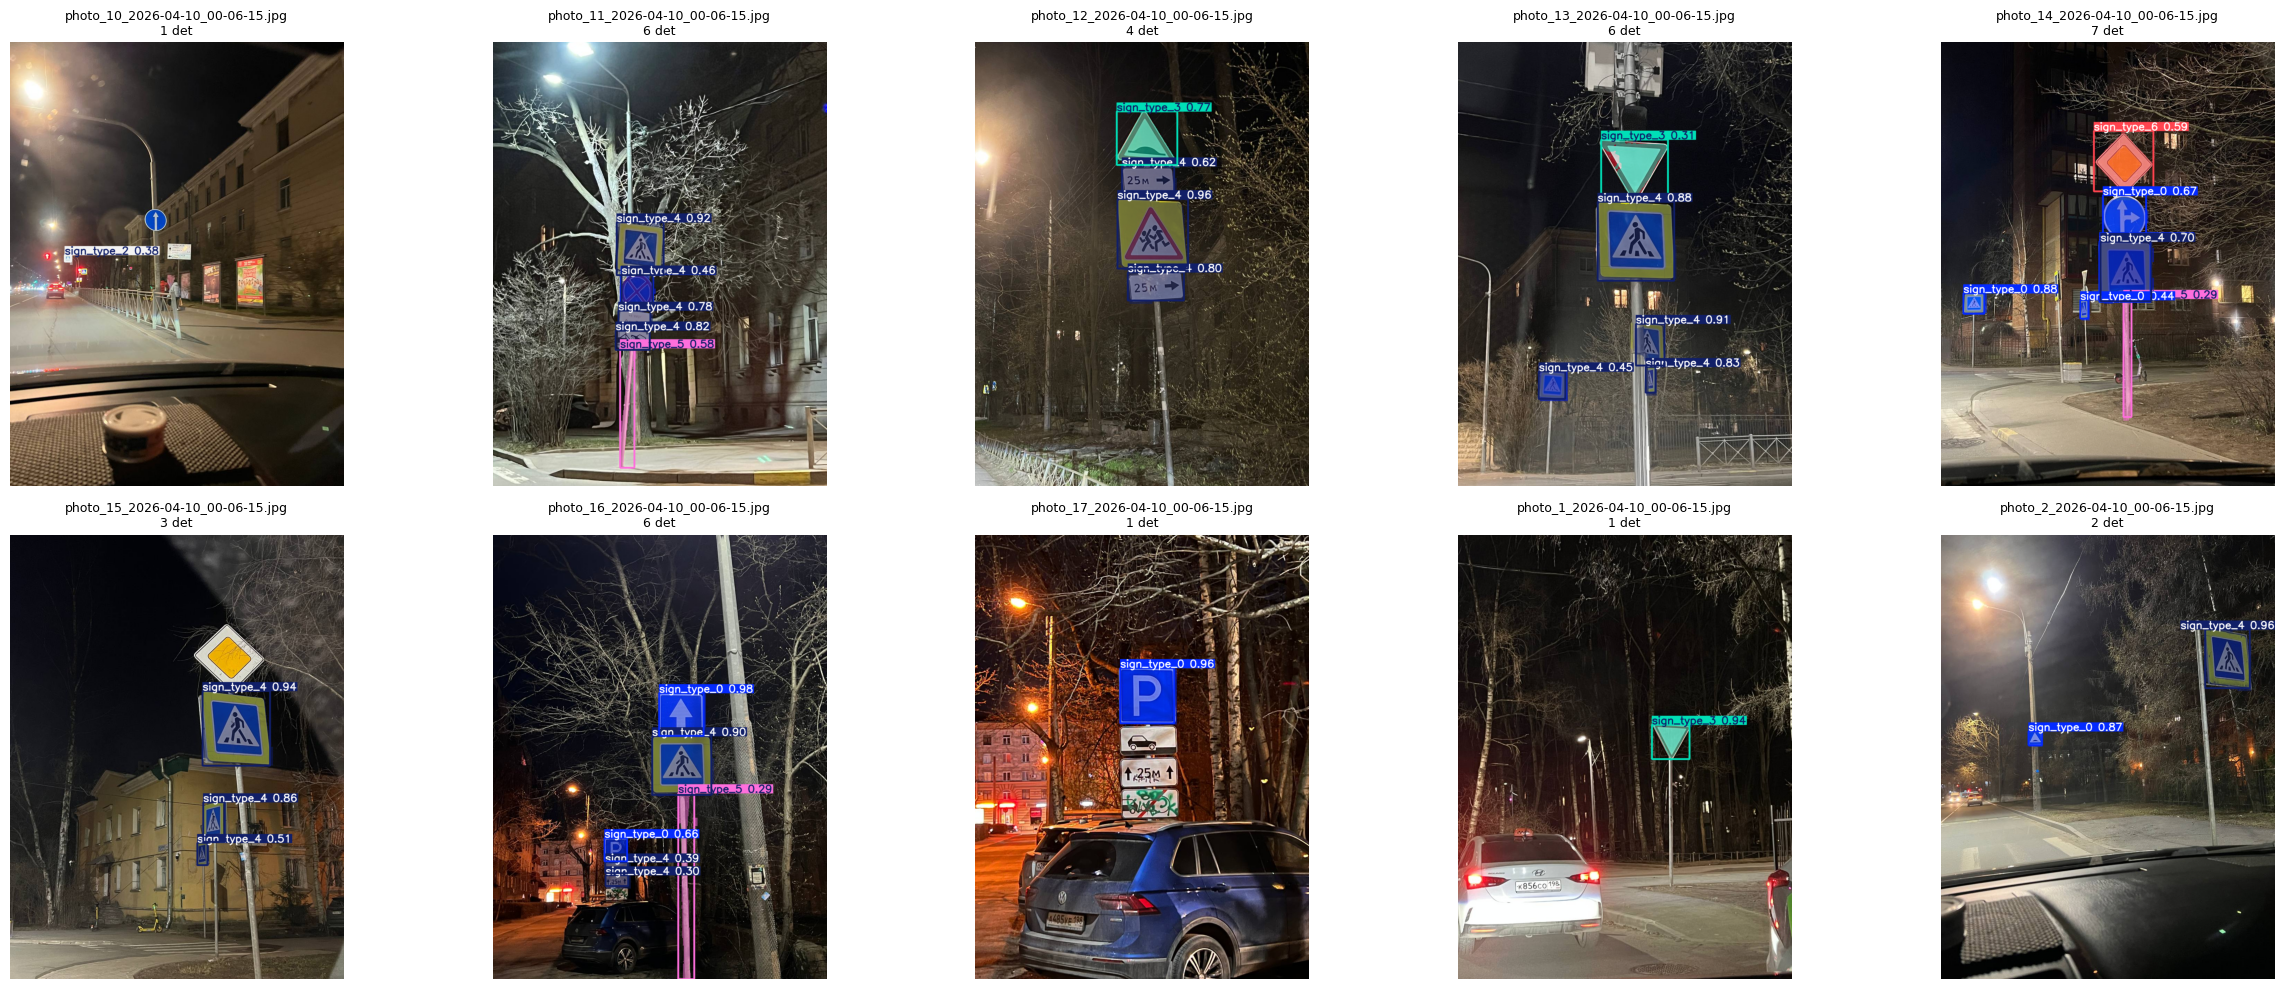

In [44]:
test_imgs = sorted(glob.glob(os.path.join(TEST_PHOTOS_DIR, '*.*')))
n = min(len(test_imgs), 10)
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()
for i, p in enumerate(test_imgs[:10]):
    img = cv2.imread(p)
    res = model.predict(img, verbose=False, device=DEVICE, imgsz=640, conf=0.25)[0]
    axes[i].imshow(cv2.cvtColor(res.plot(), cv2.COLOR_BGR2RGB))
    nd = len(res.boxes) if res.boxes is not None else 0
    axes[i].set_title(f'{Path(p).name}\n{nd} det', fontsize=9)
    axes[i].axis('off')
for j in range(n, 10): axes[j].axis('off')
plt.tight_layout();
plt.savefig('test_results.png', dpi=150);
plt.show()